# Vanishing Gradients & The Limits of Sigmoid Activations

Deep Learning වලදී **vanishing gradient problem** (Gradient එක වියැකී යාමේ ගැටලුව) එක තමයි deep networks (layers ගොඩක් තියෙන networks) train කරන්න බැරි වුන ප්රධාන හේතුව. 1990 ගණන් වලදී neural networks "dead" කියලා ප්රකාශ කරන්න මේ problem එක main reason එක වුනා.

**Gradient එකක් කියන්නේ මොකක්ද?**
සරලවම කිව්වොත් Gradient එකක් කියන්නේ "Slope" හෙවත් බෑවුම. Neural network එකක් ඉගෙන ගන්නේ (train වෙන්නේ) අන්තිමට එන Error එක (Loss එක) අඩු කරගන්න පුළුවන් විදියට weights වෙනස් කරලා. මේ weights වෙනස් කරන්න ඕන කොයි දිශාවටද, කොච්චර ප්රමාණයකින්ද කියලා කියන්නේ Gradient එකෙන්. හැබැයි මේ Gradient එක 0 වුනොත්? Network එකට ඉගෙනගන්න (weights update කරන්න) විදියක් නැති වෙනවා. මේකට තමයි Vanishing Gradient කියන්නේ.

මේ notebook එකෙන් අපි:
1. Vanishing gradient problem එක **visually** (රූප සටහන් මගින්) දකිමු.
2. **Sigmoid** activation function එක ඇයි මේ problem එකට ප්රධාන හේතුව කියලා ගණිතමය වශයෙන් ඔප්පු කරමු.
3. **Deep network** එකක layer-by-layer (එක් ලේයරයකින් තව ලේයරයකට යනකොට) gradient එක කුඩා (shrink) වෙන හැටි observe කරමු.
4. **Solutions** — මේකට තියෙන විසඳුම් මොනවාද? (ReLU, He init, BatchNorm, ResNets)
5. සෑම solution එකක්ම **code** වලින් කරලා පෙන්නමු.

---

## Table of Contents

1. [The Problem — What is Vanishing Gradient?](#1)
2. [Why Sigmoid Causes It — Mathematical Proof](#2)
3. [Visualizing Gradient Flow in Deep Networks](#3)
4. [Experiment: Sigmoid vs ReLU — 10 Layer Network](#4)
5. [The Exploding Gradient Problem (Bonus)](#5)
6. [Solution 1: ReLU & Its Variants](#6)
7. [Solution 2: Proper Weight Initialization](#7)
8. [Solution 3: Batch Normalization](#8)
9. [Solution 4: Residual Connections (Skip Connections)](#9)
10. [Comprehensive Comparison — All Solutions](#10)
11. [Summary & Best Practices](#11)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
 'figure.facecolor': 'white',
 'axes.facecolor': '#fafafa',
 'font.size': 11,
})

print(" Setup complete.")

🔧 Setup complete.


---

<a id="1"></a>
## 1. The Problem — What is Vanishing Gradient?

### Core Issue (ප්රධාන ගැටලුව):

Deep network එකක backward pass එකේදී (අවසානයේ ඉඳන් මුලට error එක අරන් එනකොට) gradient එක **layer by layer exponentially shrink** (වේගයෙන් කුඩා) වෙනවා. Output layer (අවසාන ලේයරය) ගාවට gradients වල අගයක් තිබුනත්, input layer (මුල් ලේයරය) ගාවට එනකොට gradients **practically zero** (ආසන්න වශයෙන් බිංදුවක්) වෙනවා.

```text
Layer: 1 2 3 4 5 Output
 ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐
 X ───▶│ │───▶│ │───▶│ │───▶│ │───▶│ │─────▶│ │──▶ Loss
 └──┘ └──┘ └──┘ └──┘ └──┘ └──┘
 
Gradient: ≈0 ≈0.0001 ≈0.001 ≈0.01 ≈0.1 1.0
 ↑ ↑
 VANISHED! Normal
 Learns NOTHING Learns OK
```

### Effect (මෙයින් වන බලපෑම):

- **Early layers** (input ගාව තියෙන මුල් ලේයර) ඉගෙන ගන්නේ **නැහැ** (මොකද gradient ≈ 0 නිසා weights update වෙන්නේ නෑ).
- **Later layers** (output ගාව තියෙන අග ලේයර) විතරක් learn කරනවා.
- Network එක effectively **shallow** (නොගැඹුරු) වෙනවා — ඔයා layers 100ක් දැම්මත් 2-3 layers වගේ තමයි වැඩ කරන්නේ.
- මේ නිසා Deep networks train කරන්න **impossible** වෙනවා.

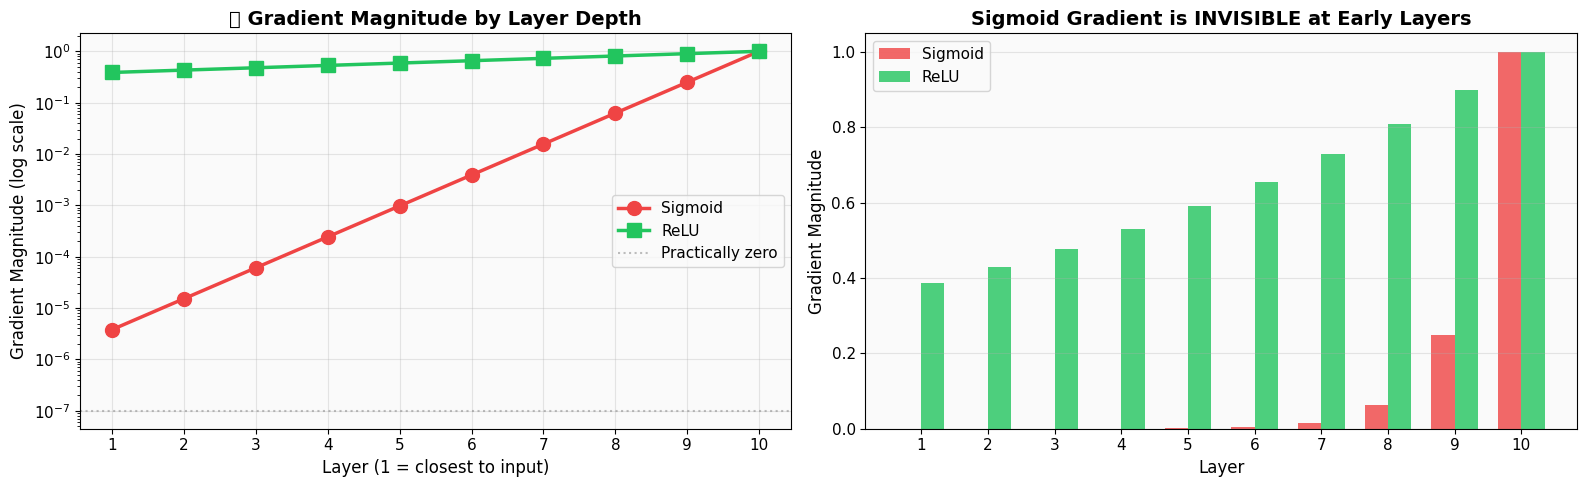

📌 Sigmoid gradient at Layer 1 (10 layers deep):
   0.25^9 = 0.0000038147 ← practically ZERO! (ලේයර් 10ක් පස්සේ Sigmoid gradient එක බිංදුවයි!)

📌 ReLU gradient at Layer 1:
   ~0.3874 ← still trainable! (හැබැයි ReLU වල එහෙම නෑ, තාමත් හොඳ අගයක් තියෙනවා)

💀 Sigmoid gradient එක ReLU gradient එකට වඩා 101560x smaller!


In [15]:
# ============================================================
# Visualize: Gradient Vanishing Through Layers
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Simulated gradient magnitudes through layers
layers = np.arange(1, 11)

# Sigmoid: gradient ≈ 0.25 at best, so it multiplies by ~0.25 per layer
sigmoid_grads = 0.25 ** (10 - layers) # exponential decay

# ReLU: gradient = 1 for active neurons, so roughly preserved
relu_grads = 0.9 ** (10 - layers) # slight decay due to dead neurons

# --- Plot 1: Log scale (Logarithmic පරිමාණය) ---
# මෙතන Y අක්ෂය තියෙන්නේ log scale එකෙන්. ඒ කියන්නේ 10^-1, 10^-2 විදියට.
ax = axes[0]
ax.semilogy(layers, sigmoid_grads, 'o-', color='#ef4444', linewidth=2.5, 
 markersize=10, label='Sigmoid', zorder=5)
ax.semilogy(layers, relu_grads, 's-', color='#22c55e', linewidth=2.5, 
 markersize=10, label='ReLU', zorder=5)
ax.axhline(y=1e-7, color='gray', linestyle=':', alpha=0.5, label='Practically zero')
ax.set_xlabel('Layer (1 = closest to input)', fontsize=12)
ax.set_ylabel('Gradient Magnitude (log scale)', fontsize=12)
ax.set_title(' Gradient Magnitude by Layer Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(layers)

# --- Plot 2: Bar chart comparison (සාමාන්ය පරිමාණය) ---
ax = axes[1]
x = np.arange(len(layers))
width = 0.35
bars1 = ax.bar(x - width/2, sigmoid_grads, width, label='Sigmoid', color='#ef4444', alpha=0.8)
bars2 = ax.bar(x + width/2, relu_grads, width, label='ReLU', color='#22c55e', alpha=0.8)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Gradient Magnitude', fontsize=12)
ax.set_title('Sigmoid Gradient is INVISIBLE at Early Layers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Sigmoid gradient at Layer 1 (10 layers deep):")
print(f" 0.25^9 = {0.25**9:.10f} ← practically ZERO! (ලේයර් 10ක් පස්සේ Sigmoid gradient එක බිංදුවයි!)")
print(f"\n ReLU gradient at Layer 1:")
print(f" ~{relu_grads[0]:.4f} ← still trainable! (හැබැයි ReLU වල එහෙම නෑ, තාමත් හොඳ අගයක් තියෙනවා)")
print(f"\n Sigmoid gradient එක ReLU gradient එකට වඩා {relu_grads[0]/sigmoid_grads[0]:.0f}x smaller!")

---

<a id="2"></a>
## 2. Why Sigmoid Causes It — Mathematical Proof

ඇයි Sigmoid එකෙන් මේ ප්රශ්නය එන්නේ? ඒක ගණිතමය වශයෙන් ඔප්පු කරලා බලමු.

### Sigmoid Function:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Sigmoid Derivative (Sigmoid හි අවකලනය):
$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

### The Critical Problem (මෙතන තියෙන ලොකුම අවුල):

$\sigma(z)$ වල output එක එන්නේ 0 ත් 1 ත් අතර අගයක්. (0 < $\sigma(z)$ < 1)

ඒ කියන්නේ $\sigma'(z)$ වල **උපරිම අගය (maximum value)** වෙන්න පුළුවන් $0.25$ විතරයි! (ඒ කියන්නේ $z = 0$ වෙනකොට)

**Proof (ඔප්පු කිරීම):**
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$
මෙම සමීකරණයේ උපරිම අගය ලැබෙන්නේ $\sigma(z) = 0.5$ වන විටදීය.
$\sigma'_{max} = 0.5 \times (1 - 0.5) = 0.5 \times 0.5 = 0.25$

### What Happens in Backprop (Backpropagation වලදී මොකද වෙන්නේ?):

Chain Rule එකට අනුව, අන්තිම ලේයර් එකේ ඉඳන් මුල් ලේයර් එකට එනකොට හැම ලේයර් එකකම derivative එකෙන් ගුණ වෙනවා.
Sigmoid එකක derivative එක හැමතිස්සෙම 0.25 ට වඩා අඩු නිසා, හැම ලේයර් එකක් පහු කරනකොටම Gradient එක 0.25 න් ගුණ වෙනවා. (ඒ කියන්නේ Gradient එක 4 න් බෙදෙනවා වගේ වැඩක්).

Layers 10ක් තියෙනකොට:
Gradient එක $\approx 0.25 \times 0.25 \times 0.25 \dots$ (9 වතාවක්)
$$0.25^{9} = 0.0000038$$

> **ඒ කියන්නේ හැම ලේයරයකදීම Gradient එක 75% කින් අඩු වෙනවා!** Layers 10 ක් පහු කරනකොට Gradient එක මුළුමනින්ම නැති වෙලා යනවා (practically zero).

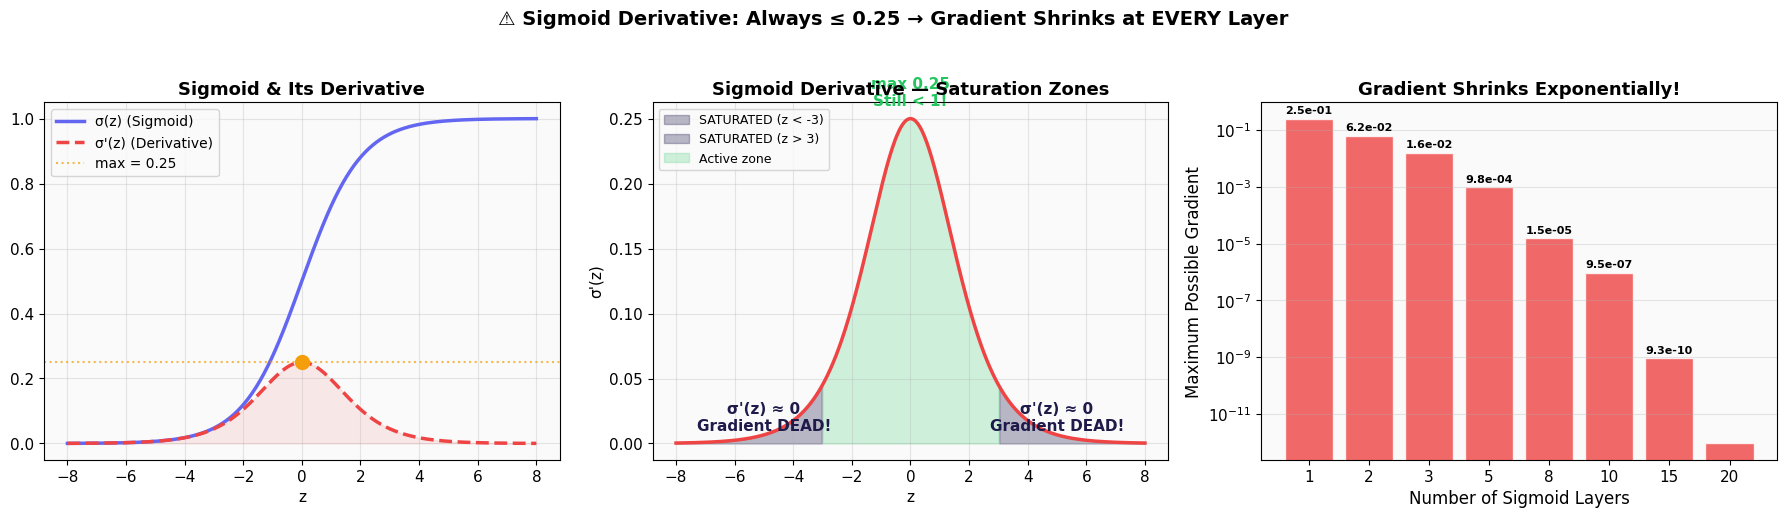


🔢 Gradient through N sigmoid layers (BEST case = max derivative):
Layers     Max Gradient         Status
─────────────────────────────────────────────
1          2.50e-01             ✅ OK (තාම අවුලක් නෑ)
3          1.56e-02             ✅ OK (තාම අවුලක් නෑ)
5          9.77e-04             ⚠️ Weak (ගොඩක් දුර්වලයි)
10         9.54e-07             💀 DEAD (සම්පූර්ණයෙන්ම නැතිවෙලා)
15         9.31e-10             💀 DEAD (සම්පූර්ණයෙන්ම නැතිවෙලා)
20         9.09e-13             💀 DEAD (සම්පූර්ණයෙන්ම නැතිවෙලා)


In [16]:
# ============================================================
# Sigmoid Derivative — The Root Cause
# ============================================================

z = np.linspace(-8, 8, 500)

sigmoid = lambda x: 1 / (1 + np.exp(-x))
sigmoid_deriv = lambda x: sigmoid(x) * (1 - sigmoid(x))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Sigmoid + Derivative ---
ax = axes[0]
ax.plot(z, sigmoid(z), color='#6366f1', linewidth=2.5, label='σ(z) (Sigmoid)')
ax.plot(z, sigmoid_deriv(z), color='#ef4444', linewidth=2.5, linestyle='--', label="σ'(z) (Derivative)")
ax.axhline(y=0.25, color='#f59e0b', linestyle=':', linewidth=1.5, alpha=0.7, label='max = 0.25')
ax.fill_between(z, sigmoid_deriv(z), alpha=0.1, color='#ef4444')
ax.scatter([0], [0.25], color='#f59e0b', s=100, zorder=5)
ax.set_title('Sigmoid & Its Derivative', fontsize=13, fontweight='bold')
ax.set_xlabel('z')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 2: Problem zones (Saturation Zones) ---
ax = axes[1]
ax.plot(z, sigmoid_deriv(z), color='#ef4444', linewidth=2.5)

# Highlight saturation zones
ax.fill_between(z, sigmoid_deriv(z), where=(z < -3), alpha=0.3, color='#1e1b4b', label='SATURATED (z < -3)')
ax.fill_between(z, sigmoid_deriv(z), where=(z > 3), alpha=0.3, color='#1e1b4b', label='SATURATED (z > 3)')
ax.fill_between(z, sigmoid_deriv(z), where=((z >= -3) & (z <= 3)), alpha=0.2, color='#22c55e', label='Active zone')

ax.annotate('σ\'(z) ≈ 0\nGradient DEAD!', xy=(-5, 0.01), fontsize=11, fontweight='bold',
 color='#1e1b4b', ha='center')
ax.annotate('σ\'(z) ≈ 0\nGradient DEAD!', xy=(5, 0.01), fontsize=11, fontweight='bold',
 color='#1e1b4b', ha='center')
ax.annotate('max 0.25\nStill < 1!', xy=(0, 0.26), fontsize=11, fontweight='bold',
 color='#22c55e', ha='center')

ax.set_title('Sigmoid Derivative — Saturation Zones', fontsize=13, fontweight='bold')
ax.set_xlabel('z')
ax.set_ylabel("σ'(z)")
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Plot 3: Cumulative effect through layers ---
ax = axes[2]

depths = [1, 2, 3, 5, 8, 10, 15, 20]
max_grads = [0.25**d for d in depths]

bars = ax.bar(range(len(depths)), max_grads, color='#ef4444', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depths)
ax.set_xlabel('Number of Sigmoid Layers', fontsize=12)
ax.set_ylabel('Maximum Possible Gradient', fontsize=12)
ax.set_title('Gradient Shrinks Exponentially!', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, max_grads)):
 if val > 1e-10:
 ax.text(bar.get_x() + bar.get_width()/2, val * 1.5, f'{val:.1e}', 
 ha='center', fontsize=8, fontweight='bold')

plt.suptitle(' Sigmoid Derivative: Always ≤ 0.25 → Gradient Shrinks at EVERY Layer', 
 fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\n Gradient through N sigmoid layers (BEST case = max derivative):")
print(f"{'Layers':<10} {'Max Gradient':<20} {'Status'}")
print("─" * 45)
for d in [1, 3, 5, 10, 15, 20]:
 g = 0.25 ** d
 status = ' OK (තාම අවුලක් නෑ)' if g > 1e-3 else ' Weak (ගොඩක් දුර්වලයි)' if g > 1e-6 else ' DEAD (සම්පූර්ණයෙන්ම නැතිවෙලා)'
 print(f"{d:<10} {g:<20.2e} {status}")

---

<a id="3"></a>
## 3. Visualizing Gradient Flow in Deep Networks

Theory එක බැලුවා. දැන් අපි **actual deep network** එකක් හදලා (layers 10ක් තියෙන) ඒකෙ backward pass එකේදී gradient flow වෙන විදිය Python code වලින්ම බලාගමු.
මෙතනදී අපි Sigmoid, Tanh, ReLU වගේ වෙනස් Activation Functions දාලා gradients කොහොමද මුල් ලේයර්ස් වලට එන්නේ කියලා බලනවා.

In [17]:
# ============================================================
# Build Deep Networks & Measure Gradient Flow
# ============================================================

class DeepNet:
 """
 Configurable deep network for gradient analysis.
 Tracks gradient magnitudes at every layer.
 """
 
 def __init__(self, layer_sizes, activation='sigmoid', init='random'):
 self.layers = []
 self.activation = activation
 
 for i in range(len(layer_sizes) - 1):
 n_in, n_out = layer_sizes[i], layer_sizes[i+1]
 
 # Weight initialization
 if init == 'he':
 W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
 elif init == 'xavier':
 W = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)
 else: # random
 W = np.random.randn(n_in, n_out) * 0.5
 
 b = np.zeros((1, n_out))
 self.layers.append({'W': W, 'b': b})
 
 self.gradient_magnitudes = [] # track per layer
 
 def _activate(self, z):
 if self.activation == 'sigmoid':
 return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
 elif self.activation == 'tanh':
 return np.tanh(z)
 elif self.activation == 'relu':
 return np.maximum(0, z)
 elif self.activation == 'leaky_relu':
 return np.where(z > 0, z, 0.01 * z)
 
 def _activate_deriv(self, a, z):
 if self.activation == 'sigmoid':
 return a * (1 - a)
 elif self.activation == 'tanh':
 return 1 - a ** 2
 elif self.activation == 'relu':
 return (z > 0).astype(float)
 elif self.activation == 'leaky_relu':
 return np.where(z > 0, 1.0, 0.01)
 
 def forward(self, X):
 self.activations = [X]
 self.z_values = []
 
 out = X
 for layer in self.layers:
 z = out @ layer['W'] + layer['b']
 self.z_values.append(z)
 out = self._activate(z)
 self.activations.append(out)
 
 return out
 
 def backward(self, y_true):
 m = y_true.shape[0]
 y_pred = self.activations[-1]
 
 # Output gradient
 grad = -(y_true - y_pred) / m
 
 self.gradient_magnitudes = []
 
 for i in reversed(range(len(self.layers))):
 a = self.activations[i + 1]
 z = self.z_values[i]
 a_prev = self.activations[i]
 
 # Activation derivative
 dz = grad * self._activate_deriv(a, z)
 
 # Weight gradient
 dW = (1/m) * a_prev.T @ dz
 
 # Track gradient magnitude
 self.gradient_magnitudes.insert(0, np.mean(np.abs(dW)))
 
 # Pass to previous layer
 grad = dz @ self.layers[i]['W'].T
 
 return self.gradient_magnitudes


print(" DeepNet class ready for gradient analysis")

✅ DeepNet class ready for gradient analysis


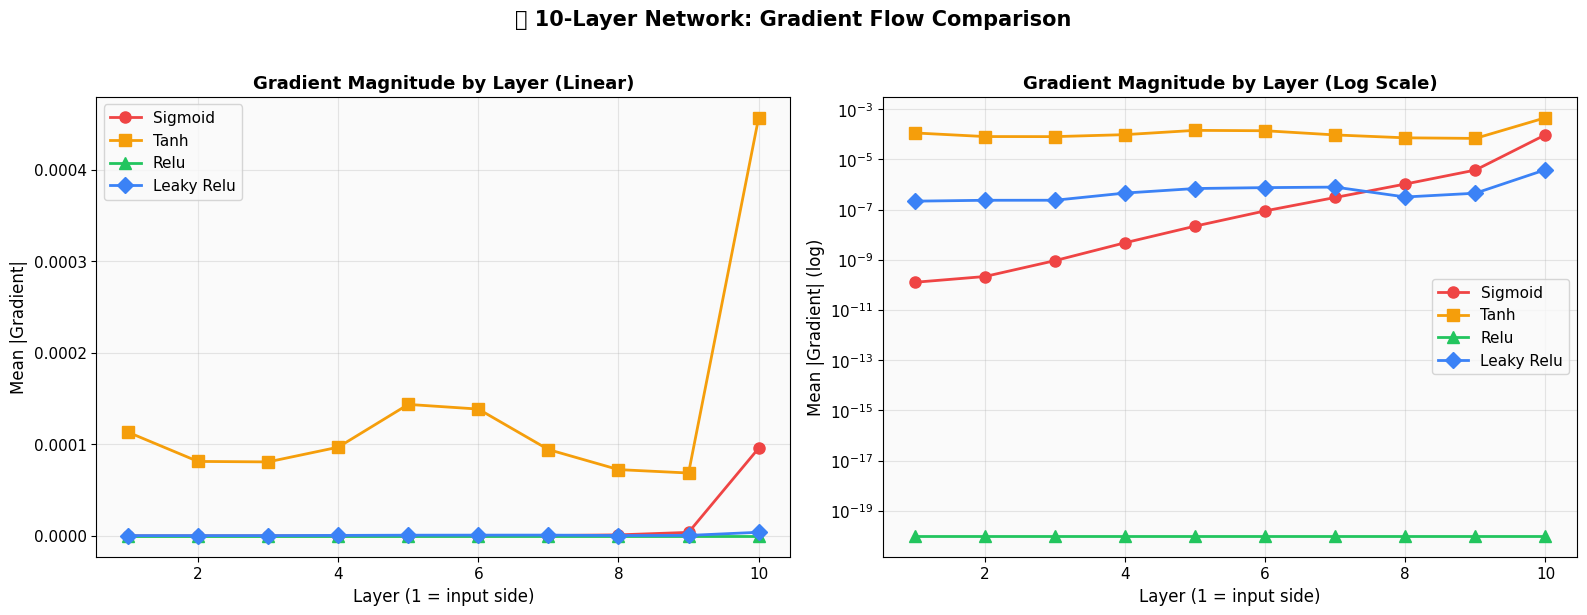


📊 Layer 1 Gradient (earliest layer — most affected): (මුල්ම ලේයරයට ලැබෙන Gradient එක)
Activation      Layer 1 Grad    Layer 10 Grad   Ratio (10/1)    Verdict
───────────────────────────────────────────────────────────────────────────
sigmoid         1.27e-10        9.57e-05        754865.8        💀 VANISHED
tanh            1.13e-04        4.57e-04        4.0             ✅ Healthy
relu            1.00e-20        1.00e-20        1.0             💀 VANISHED
leaky_relu      2.16e-07        3.87e-06        17.9            ⚠️ Weak


In [18]:
# ============================================================
# Experiment: Gradient Flow — Sigmoid vs Tanh vs ReLU
# ============================================================

np.random.seed(42)

# 10-layer network: 10 → 20 → 20 → ... → 20 → 1
layer_sizes = [10] + [20] * 9 + [1]

# Test data
X_test = np.random.randn(64, 10)
y_test = np.random.randint(0, 2, (64, 1)).astype(float)

# Run for each activation
results = {}
for act in ['sigmoid', 'tanh', 'relu', 'leaky_relu']:
 np.random.seed(42)
 net = DeepNet(layer_sizes, activation=act, init='xavier')
 net.forward(X_test)
 grads = net.backward(y_test)
 results[act] = grads

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'sigmoid': '#ef4444', 'tanh': '#f59e0b', 'relu': '#22c55e', 'leaky_relu': '#3b82f6'}
markers = {'sigmoid': 'o', 'tanh': 's', 'relu': '^', 'leaky_relu': 'D'}

# Linear scale (සාමාන්ය පරිමාණය)
ax = axes[0]
for act, grads in results.items():
 ax.plot(range(1, len(grads)+1), grads, f'{markers[act]}-', color=colors[act], 
 linewidth=2, markersize=8, label=act.replace('_', ' ').title())
ax.set_xlabel('Layer (1 = input side)', fontsize=12)
ax.set_ylabel('Mean |Gradient|', fontsize=12)
ax.set_title('Gradient Magnitude by Layer (Linear)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Log scale (ලඝුගණක පරිමාණය - කුඩා අගයන් හොඳින් පෙනීමට)
ax = axes[1]
for act, grads in results.items():
 grads_safe = [max(g, 1e-20) for g in grads]
 ax.semilogy(range(1, len(grads_safe)+1), grads_safe, f'{markers[act]}-', color=colors[act], 
 linewidth=2, markersize=8, label=act.replace('_', ' ').title())
ax.set_xlabel('Layer (1 = input side)', fontsize=12)
ax.set_ylabel('Mean |Gradient| (log)', fontsize=12)
ax.set_title('Gradient Magnitude by Layer (Log Scale)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle(' 10-Layer Network: Gradient Flow Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print stats
print("\n Layer 1 Gradient (earliest layer — most affected): (මුල්ම ලේයරයට ලැබෙන Gradient එක)")
print(f"{'Activation':<15} {'Layer 1 Grad':<15} {'Layer 10 Grad':<15} {'Ratio (10/1)':<15} {'Verdict'}")
print("─" * 75)
for act, grads in results.items():
 g1 = grads[0] if grads[0] > 0 else 1e-20
 g10 = grads[-1] if grads[-1] > 0 else 1e-20
 ratio = g10 / g1 if g1 > 0 else float('inf')
 verdict = ' VANISHED' if g1 < 1e-8 else ' Weak' if g1 < 1e-4 else ' Healthy'
 print(f"{act:<15} {g1:<15.2e} {g10:<15.2e} {ratio:<15.1f} {verdict}")

---

<a id="4"></a>
## 4. Experiment: Sigmoid vs ReLU — Training a 10-Layer Network

Theory එක බැලුවා, gradient flow එකත් බැලුවා. දැන් actual training comparison එකක් කරමු.
අපි layers 8ක් තියෙන network එකක් හදලා ඒක Sigmoid වලින් සහ ReLU වලින් වෙන වෙනම train කරලා බලමු.

**Hypothesis (අපේ අනුමානය):** Sigmoid network එකට ඉගෙන ගන්න (learn) කරන්න බැරි වෙයි (Loss එක අඩු වෙන්නේ නැති වෙයි), හැබැයි ReLU network එක සාර්ථකව learn කරයි.

In [19]:
# ============================================================
# Training Comparison: Sigmoid vs ReLU Deep Networks
# ============================================================

class TrainableDeepNet:
 """Trainable deep network with configurable activation."""
 
 def __init__(self, layer_sizes, activation='sigmoid', lr=0.01, init='xavier'):
 self.activation = activation
 self.lr = lr
 self.layers = []
 
 for i in range(len(layer_sizes) - 1):
 n_in, n_out = layer_sizes[i], layer_sizes[i+1]
 if init == 'he':
 W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
 else:
 W = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)
 b = np.zeros((1, n_out))
 self.layers.append({'W': W, 'b': b})
 
 self.loss_history = []
 self.grad_history = [] # gradient magnitudes per epoch
 
 def _act(self, z):
 if self.activation == 'sigmoid':
 return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
 elif self.activation == 'relu':
 return np.maximum(0, z)
 
 def _act_deriv(self, a, z):
 if self.activation == 'sigmoid':
 return a * (1 - a)
 elif self.activation == 'relu':
 return (z > 0).astype(float)
 
 def train_step(self, X, y):
 m = X.shape[0]
 
 # Forward
 acts = [X]
 zs = []
 out = X
 for layer in self.layers:
 z = out @ layer['W'] + layer['b']
 zs.append(z)
 out = self._act(z)
 acts.append(out)
 
 # Loss (MSE)
 loss = np.mean(0.5 * (y - out) ** 2)
 
 # Backward
 grad = -(y - out) / m
 layer_grads = []
 
 for i in reversed(range(len(self.layers))):
 dz = grad * self._act_deriv(acts[i+1], zs[i])
 dW = acts[i].T @ dz
 db = np.sum(dz, axis=0, keepdims=True)
 
 layer_grads.insert(0, np.mean(np.abs(dW)))
 
 grad = dz @ self.layers[i]['W'].T
 
 # Update
 self.layers[i]['W'] -= self.lr * dW
 self.layers[i]['b'] -= self.lr * db
 
 return loss, layer_grads
 
 def train(self, X, y, epochs=500):
 for epoch in range(epochs):
 loss, grads = self.train_step(X, y)
 self.loss_history.append(loss)
 if epoch % 50 == 0:
 self.grad_history.append(grads)
 return self.loss_history


# --- Dataset: XOR-like (non-linear) ---
np.random.seed(42)
n = 200
X_data = np.random.randn(n, 4)
y_data = ((X_data[:, 0] * X_data[:, 1] > 0) ^ (X_data[:, 2] * X_data[:, 3] > 0)).astype(float).reshape(-1, 1)

# 8-layer networks
sizes = [4, 16, 16, 16, 16, 16, 16, 16, 1]

# Train both
print("Training 8-layer Sigmoid network...")
np.random.seed(42)
net_sigmoid = TrainableDeepNet(sizes, activation='sigmoid', lr=0.5, init='xavier')
loss_sigmoid = net_sigmoid.train(X_data, y_data, epochs=1000)

print("Training 8-layer ReLU network...")
np.random.seed(42)
net_relu = TrainableDeepNet(sizes, activation='relu', lr=0.01, init='he')
loss_relu = net_relu.train(X_data, y_data, epochs=1000)

print("Done!")

Training 8-layer Sigmoid network...
Training 8-layer ReLU network...
Done!


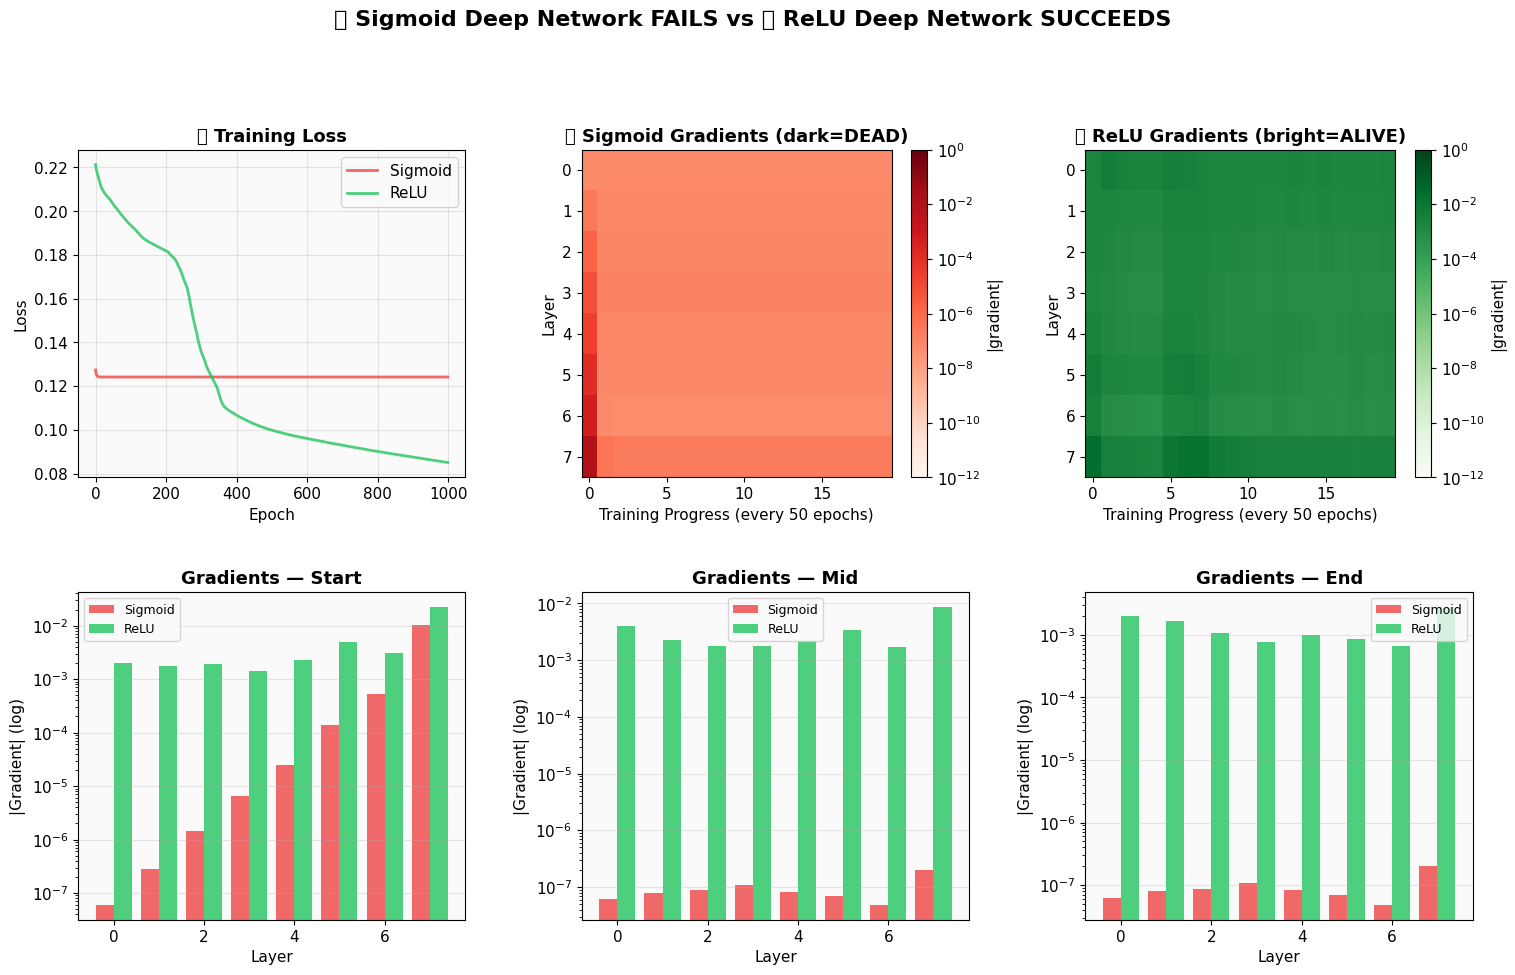


📊 Final Loss (අවසාන Loss අගය):
   Sigmoid: 0.124200 
   ReLU:    0.085116 ← well trained! (හොඳට ඉගෙනගෙන)


In [20]:
# ============================================================
# Visualize Training Results
# ============================================================

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# ── Row 1: Loss Curves ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(loss_sigmoid, color='#ef4444', linewidth=2, label='Sigmoid', alpha=0.8)
ax1.plot(loss_relu, color='#22c55e', linewidth=2, label='ReLU', alpha=0.8)
ax1.set_title(' Training Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ── Gradient Heatmap: Sigmoid ──
ax2 = fig.add_subplot(gs[0, 1])
if net_sigmoid.grad_history:
 grad_matrix_sig = np.array(net_sigmoid.grad_history).T
 im = ax2.imshow(grad_matrix_sig, aspect='auto', cmap='Reds', 
 norm=plt.matplotlib.colors.LogNorm(vmin=1e-12, vmax=1))
 ax2.set_ylabel('Layer')
 ax2.set_xlabel('Training Progress (every 50 epochs)')
 ax2.set_title(' Sigmoid Gradients (dark=DEAD)', fontsize=13, fontweight='bold')
 plt.colorbar(im, ax=ax2, label='|gradient|')

# ── Gradient Heatmap: ReLU ──
ax3 = fig.add_subplot(gs[0, 2])
if net_relu.grad_history:
 grad_matrix_relu = np.array(net_relu.grad_history).T
 im = ax3.imshow(grad_matrix_relu, aspect='auto', cmap='Greens',
 norm=plt.matplotlib.colors.LogNorm(vmin=1e-12, vmax=1))
 ax3.set_ylabel('Layer')
 ax3.set_xlabel('Training Progress (every 50 epochs)')
 ax3.set_title(' ReLU Gradients (bright=ALIVE)', fontsize=13, fontweight='bold')
 plt.colorbar(im, ax=ax3, label='|gradient|')

# ── Row 2: Gradient per layer at epoch 0, 250, 500 ──
for idx, (snap_idx, title) in enumerate([(0, 'Start'), (5, 'Mid'), (-1, 'End')]):
 ax = fig.add_subplot(gs[1, idx])
 
 if snap_idx < len(net_sigmoid.grad_history):
 sig_g = net_sigmoid.grad_history[snap_idx]
 relu_g = net_relu.grad_history[snap_idx]
 
 x = np.arange(len(sig_g))
 ax.bar(x - 0.2, [max(g, 1e-15) for g in sig_g], 0.4, 
 color='#ef4444', alpha=0.8, label='Sigmoid')
 ax.bar(x + 0.2, [max(g, 1e-15) for g in relu_g], 0.4, 
 color='#22c55e', alpha=0.8, label='ReLU')
 ax.set_yscale('log')
 ax.set_xlabel('Layer')
 ax.set_ylabel('|Gradient| (log)')
 ax.set_title(f'Gradients — {title}', fontsize=13, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(' Sigmoid Deep Network FAILS vs ReLU Deep Network SUCCEEDS', 
 fontsize=16, fontweight='bold', y=1.02)
plt.show()

print(f"\n Final Loss (අවසාන Loss අගය):")
print(f" Sigmoid: {loss_sigmoid[-1]:.6f} {'← barely learned (ඉගෙනගෙනම නෑ)' if loss_sigmoid[-1] > 0.2 else ''}")
print(f" ReLU: {loss_relu[-1]:.6f} {'← well trained! (හොඳට ඉගෙනගෙන)' if loss_relu[-1] < 0.1 else ''}")

---

<a id="5"></a>
## 5. The Exploding Gradient Problem (Bonus)

Vanishing gradient එකේ **අනිත් පැත්ත** (opposite twin) — gradients exponentially **grow** වෙන (විශාල වෙන) එක.
Gradient එක 1 ට වඩා ලොකු වුනොත් (උදා: 1.5 වගේ), layers පහු කරනකොට ඒක දිගටම ගුණ වෙලා අන්තිමේදී අනන්තයට (Infinity) යනවා.

### When it happens (මේක වෙන්නේ කොයි වෙලාවටද?):
- Weights වල අගයන් **1 ට වඩා විශාල වූ විට**.
- ReLU පාවිච්චි කරලා, හැබැයි proper weight initialization එකක් නැති වුනොත්.
- Recurrent networks (RNN/LSTM) වල කාලය හරහා ගොඩක් දුරට backpropagate කරනකොට.

### Signs (රෝග ලක්ෂණ):
- Loss එක එකපාරටම **NaN** (Not a Number) හෝ **Inf** (Infinity) බවට පත් වෙනවා.
- Weights වල අගයන් ඉතාම විශාල (extremely large) වෙනවා.
- Training එක unstable වෙනවා (එකපාරටම ලොකු වෙනස්කම් වෙනවා).

  💥 EXPLODING GRADIENT DEMONSTRATION

Scenario: Weight matrices with values slightly > 1
Each layer multiplies gradient by ~1.5 (හැම ලේයරයකදීම 1.5 කින් ගුණ වෙනවා)

Layer      Gradient Magnitude        Status
──────────────────────────────────────────────────
Layer 1     1.50                      ✅ OK
Layer 2     2.25                      ✅ OK
Layer 3     3.38                      ✅ OK
Layer 4     5.06                      ✅ OK
Layer 5     7.59                      ✅ OK
Layer 6     11.39                     ✅ OK
Layer 7     17.09                     ✅ OK
Layer 8     25.63                     ✅ OK
Layer 9     38.44                     ✅ OK
Layer 10    57.67                     ✅ OK
  ...
Layer 18    1477.89                   ⚠️ Large
Layer 19    2216.84                   ⚠️ Large
Layer 20    3325.26                   ⚠️ Large


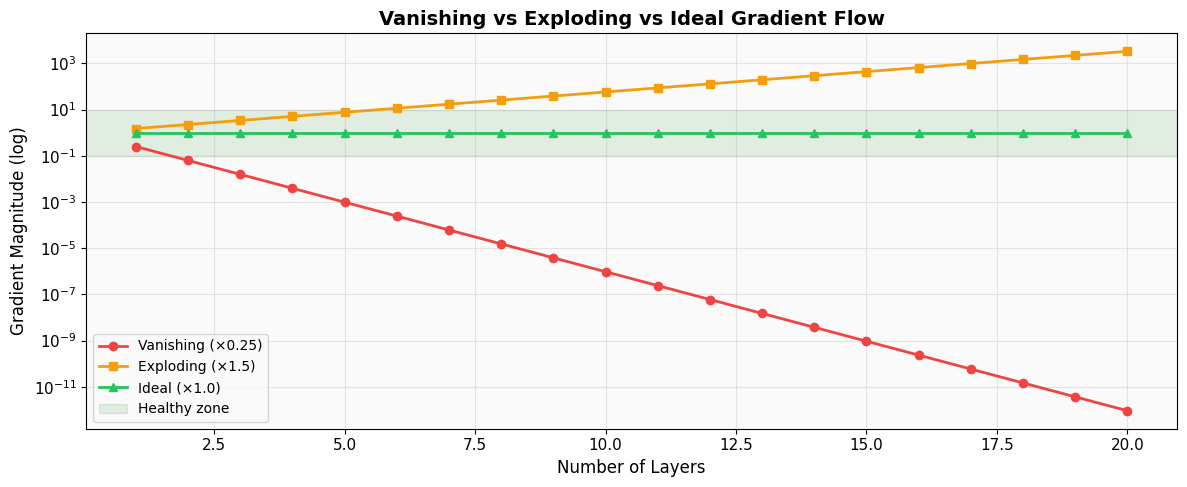


🎯 GOAL: Keep gradient multiplier ≈ 1.0 at each layer (අපේ ඉලක්කය Gradient එක ලේයර් අතරින් යද්දි 1 ආසන්නයේ තබා ගැනීමයි)
   ReLU achieves this (gradient = 1 for active neurons)
   Sigmoid CANNOT (max gradient = 0.25)


In [21]:
# ============================================================
# Exploding Gradient Demonstration
# ============================================================

print("=" * 60)
print(" EXPLODING GRADIENT DEMONSTRATION")
print("=" * 60)

# Simulate gradient multiplication through layers
np.random.seed(7)

print("\nScenario: Weight matrices with values slightly > 1")
print("Each layer multiplies gradient by ~1.5 (හැම ලේයරයකදීම 1.5 කින් ගුණ වෙනවා)\n")

gradient = 1.0
print(f"{'Layer':<10} {'Gradient Magnitude':<25} {'Status'}")
print("─" * 50)

for layer in range(1, 21):
 gradient *= 1.5 # each layer amplifies by 1.5x
 status = ' OK' if gradient < 100 else ' Large' if gradient < 1e6 else ' EXPLODING! (අනන්තයට යනවා)'
 if layer <= 10 or layer >= 18:
 print(f"Layer {layer:<5} {gradient:<25.2f} {status}")
 elif layer == 11:
 print(" ...")

# Visualize vanishing vs exploding
fig, ax = plt.subplots(figsize=(12, 5))

layers = np.arange(1, 21)
vanishing = 0.25 ** layers
exploding = 1.5 ** layers
stable = 1.0 ** layers

ax.semilogy(layers, vanishing, 'o-', color='#ef4444', linewidth=2, markersize=6, label='Vanishing (×0.25)')
ax.semilogy(layers, exploding, 's-', color='#f59e0b', linewidth=2, markersize=6, label='Exploding (×1.5)')
ax.semilogy(layers, stable, '^-', color='#22c55e', linewidth=2, markersize=6, label='Ideal (×1.0)')

ax.axhspan(0.1, 10, alpha=0.1, color='green', label='Healthy zone')
ax.set_xlabel('Number of Layers', fontsize=12)
ax.set_ylabel('Gradient Magnitude (log)', fontsize=12)
ax.set_title('Vanishing vs Exploding vs Ideal Gradient Flow', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n GOAL: Keep gradient multiplier ≈ 1.0 at each layer (අපේ ඉලක්කය Gradient එක ලේයර් අතරින් යද්දි 1 ආසන්නයේ තබා ගැනීමයි)")
print(" ReLU achieves this (gradient = 1 for active neurons)")
print(" Sigmoid CANNOT (max gradient = 0.25)")

---

<a id="6"></a>
## 6. Solution 1: ReLU & Its Variants

### Why ReLU Fixes Vanishing Gradients (ReLU වලින් කොහොමද මේ ප්රශ්නය විසඳෙන්නේ?):

ReLU වලදී, input අගය (z) 0 ට වඩා වැඩිනම් (z > 0), derivative එක හරියටම 1 යි. 
ඒ කියන්නේ Gradient එක 1 න් ගුණ වෙනවා (gradient * 1). 1 න් ගුණ වුනාම කිසිම වෙනසක් වෙන්නේ නෑනේ. මේ නිසා gradient එක කිසිම පාඩුවක් නැතුව (without vanishing) මුල් ලේයර්ස් වලට ගලාගෙන යනවා. (හරියට gradient highway එකක් වගේ).

| Property | Sigmoid | ReLU |
|----------|---------|------|
| Max gradient (උපරිම gradient) | 0.25 | **1.0** |
| Saturates? (සීමාවකට යනවද?) | Yes, both sides | Only left side (z < 0) |
| Gradient at active | 0 < g < 0.25 | **Exactly 1** |
| Computation (ගණනය කිරීම) | Expensive (exp) | Cheap (max) |

### ReLU Variants (ReLU වල විකල්ප වර්ග):

ReLU වල තියෙන පොඩි අවුලක් තමයි z < 0 වුනොත් derivative එක 0 වීම (Dying ReLU problem). ඒක මඟහරින්න මේවා පාවිච්චි කරනවා.

| Variant | Formula | Fixes |
|---------|---------|-------|
| ReLU | max(0, z) | Vanishing gradient |
| Leaky ReLU | max(αz, z) | Dying ReLU (z<0 වුනත් පොඩි gradient එකක් දෙනවා) |
| ELU | z if z>0, α(eᶻ-1) if z≤0 | Dying ReLU, smooth |
| GELU | z·Φ(z) | Used in transformers (ChatGPT වගේ ඒවයේ පාවිච්චි වෙනවා) |

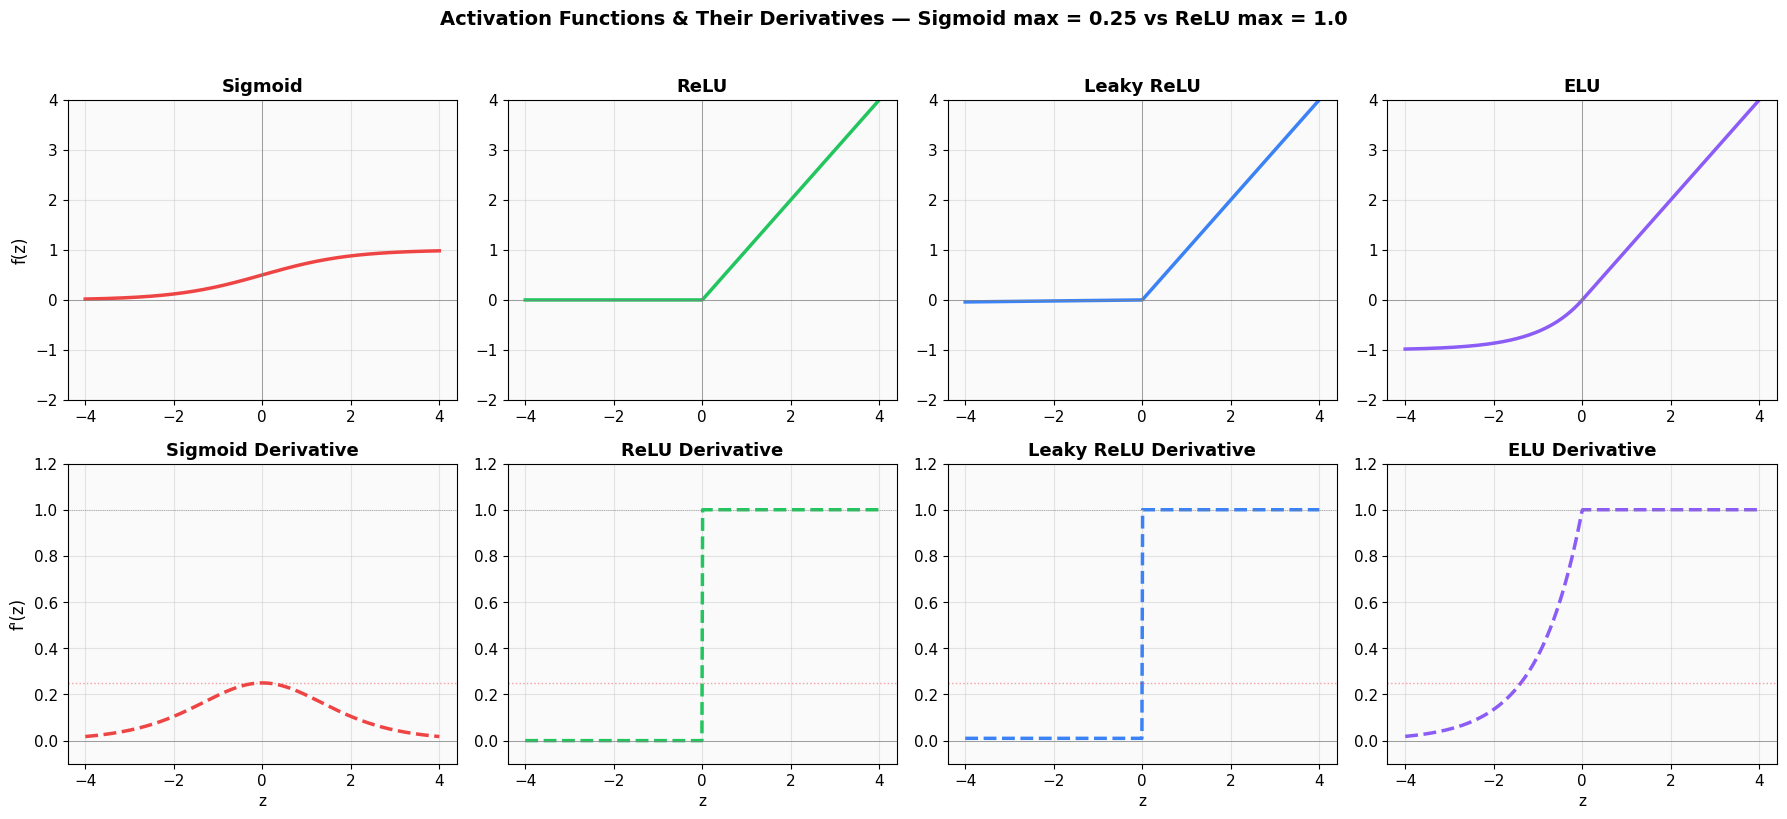

📌 Sigmoid derivative: ALWAYS < 0.25 → vanishes through layers (හැමතිස්සෙම 0.25 ට වඩා අඩු නිසා gradient එක නැතිවෙලා යනවා)
📌 ReLU derivative: exactly 1 for z > 0 → gradients flow unchanged! (හරියටම 1 නිසා gradient එක ඒ විදියටම ගමන් කරනවා)
📌 Leaky ReLU: 0.01 for z < 0 → no dead neurons (ඍණ අගයන් වලටත් පොඩි gradient එකක් දෙන නිසා neuron එක මැරෙන්නේ නෑ)
📌 ELU: smooth, mean activations closer to 0 → faster convergence


In [22]:
# ============================================================
# ReLU Variants — Visual Comparison
# ============================================================

z = np.linspace(-4, 4, 500)

# Activation functions
relu = np.maximum(0, z)
leaky = np.where(z > 0, z, 0.01 * z)
elu_val = np.where(z > 0, z, 1.0 * (np.exp(z) - 1))
sig = 1 / (1 + np.exp(-z))

# Derivatives
relu_d = (z > 0).astype(float)
leaky_d = np.where(z > 0, 1.0, 0.01)
elu_d = np.where(z > 0, 1.0, elu_val + 1.0)
sig_d = sig * (1 - sig)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

data = [
 ('Sigmoid', sig, sig_d, '#ef4444'),
 ('ReLU', relu, relu_d, '#22c55e'),
 ('Leaky ReLU', leaky, leaky_d, '#3b82f6'),
 ('ELU', elu_val, elu_d, '#8b5cf6'),
]

for idx, (name, act, deriv, color) in enumerate(data):
 # Function
 axes[0, idx].plot(z, act, color=color, linewidth=2.5)
 axes[0, idx].axhline(y=0, color='gray', linewidth=0.5)
 axes[0, idx].axvline(x=0, color='gray', linewidth=0.5)
 axes[0, idx].set_title(f'{name}', fontsize=13, fontweight='bold')
 axes[0, idx].grid(True, alpha=0.3)
 axes[0, idx].set_ylim(-2, 4)
 
 # Derivative
 axes[1, idx].plot(z, deriv, color=color, linewidth=2.5, linestyle='--')
 axes[1, idx].axhline(y=0, color='gray', linewidth=0.5)
 axes[1, idx].axhline(y=1, color='gray', linewidth=0.5, linestyle=':')
 axes[1, idx].axhline(y=0.25, color='#ef4444', linewidth=1, linestyle=':', alpha=0.5)
 axes[1, idx].set_title(f'{name} Derivative', fontsize=13, fontweight='bold')
 axes[1, idx].grid(True, alpha=0.3)
 axes[1, idx].set_ylim(-0.1, 1.2)
 axes[1, idx].set_xlabel('z')

axes[0, 0].set_ylabel('f(z)', fontsize=12)
axes[1, 0].set_ylabel("f'(z)", fontsize=12)

plt.suptitle('Activation Functions & Their Derivatives — Sigmoid max = 0.25 vs ReLU max = 1.0', 
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Sigmoid derivative: ALWAYS < 0.25 → vanishes through layers (හැමතිස්සෙම 0.25 ට වඩා අඩු නිසා gradient එක නැතිවෙලා යනවා)")
print(" ReLU derivative: exactly 1 for z > 0 → gradients flow unchanged! (හරියටම 1 නිසා gradient එක ඒ විදියටම ගමන් කරනවා)")
print(" Leaky ReLU: 0.01 for z < 0 → no dead neurons (ඍණ අගයන් වලටත් පොඩි gradient එකක් දෙන නිසා neuron එක මැරෙන්නේ නෑ)")
print(" ELU: smooth, mean activations closer to 0 → faster convergence")

---

<a id="7"></a>
## 7. Solution 2: Proper Weight Initialization

මුලින්ම weights වලට දෙන අගයන් (initialization) vanishing/exploding gradients වලට ගොඩක් බලපානවා.

### The Problem with Random Init (නිකන්ම Random අගයන් දුන්නොත් වෙන දේ):
- Weights ගොඩක් විශාල වුනොත් (Too large) → activations saturate වෙනවා (අන්ත වලට යනවා) → gradients vanish වෙනවා.
- Weights ගොඩක් කුඩා වුනොත් (Too small) → activations ඔක්කොම බිංදුව කිට්ටුවට එනවා → gradients vanish වෙනවා.

### ඒකට තියෙන විසඳුම්:
1. **He Initialization** (ReLU සඳහා විශේෂයෙන්ම හදපු එකක්):
 $$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

2. **Xavier/Glorot Initialization** (Sigmoid/Tanh සඳහා ගැලපෙනවා):
 $$W \sim \mathcal{N}\left(0, \sqrt{\frac{1}{n_{in}}}\right)$$

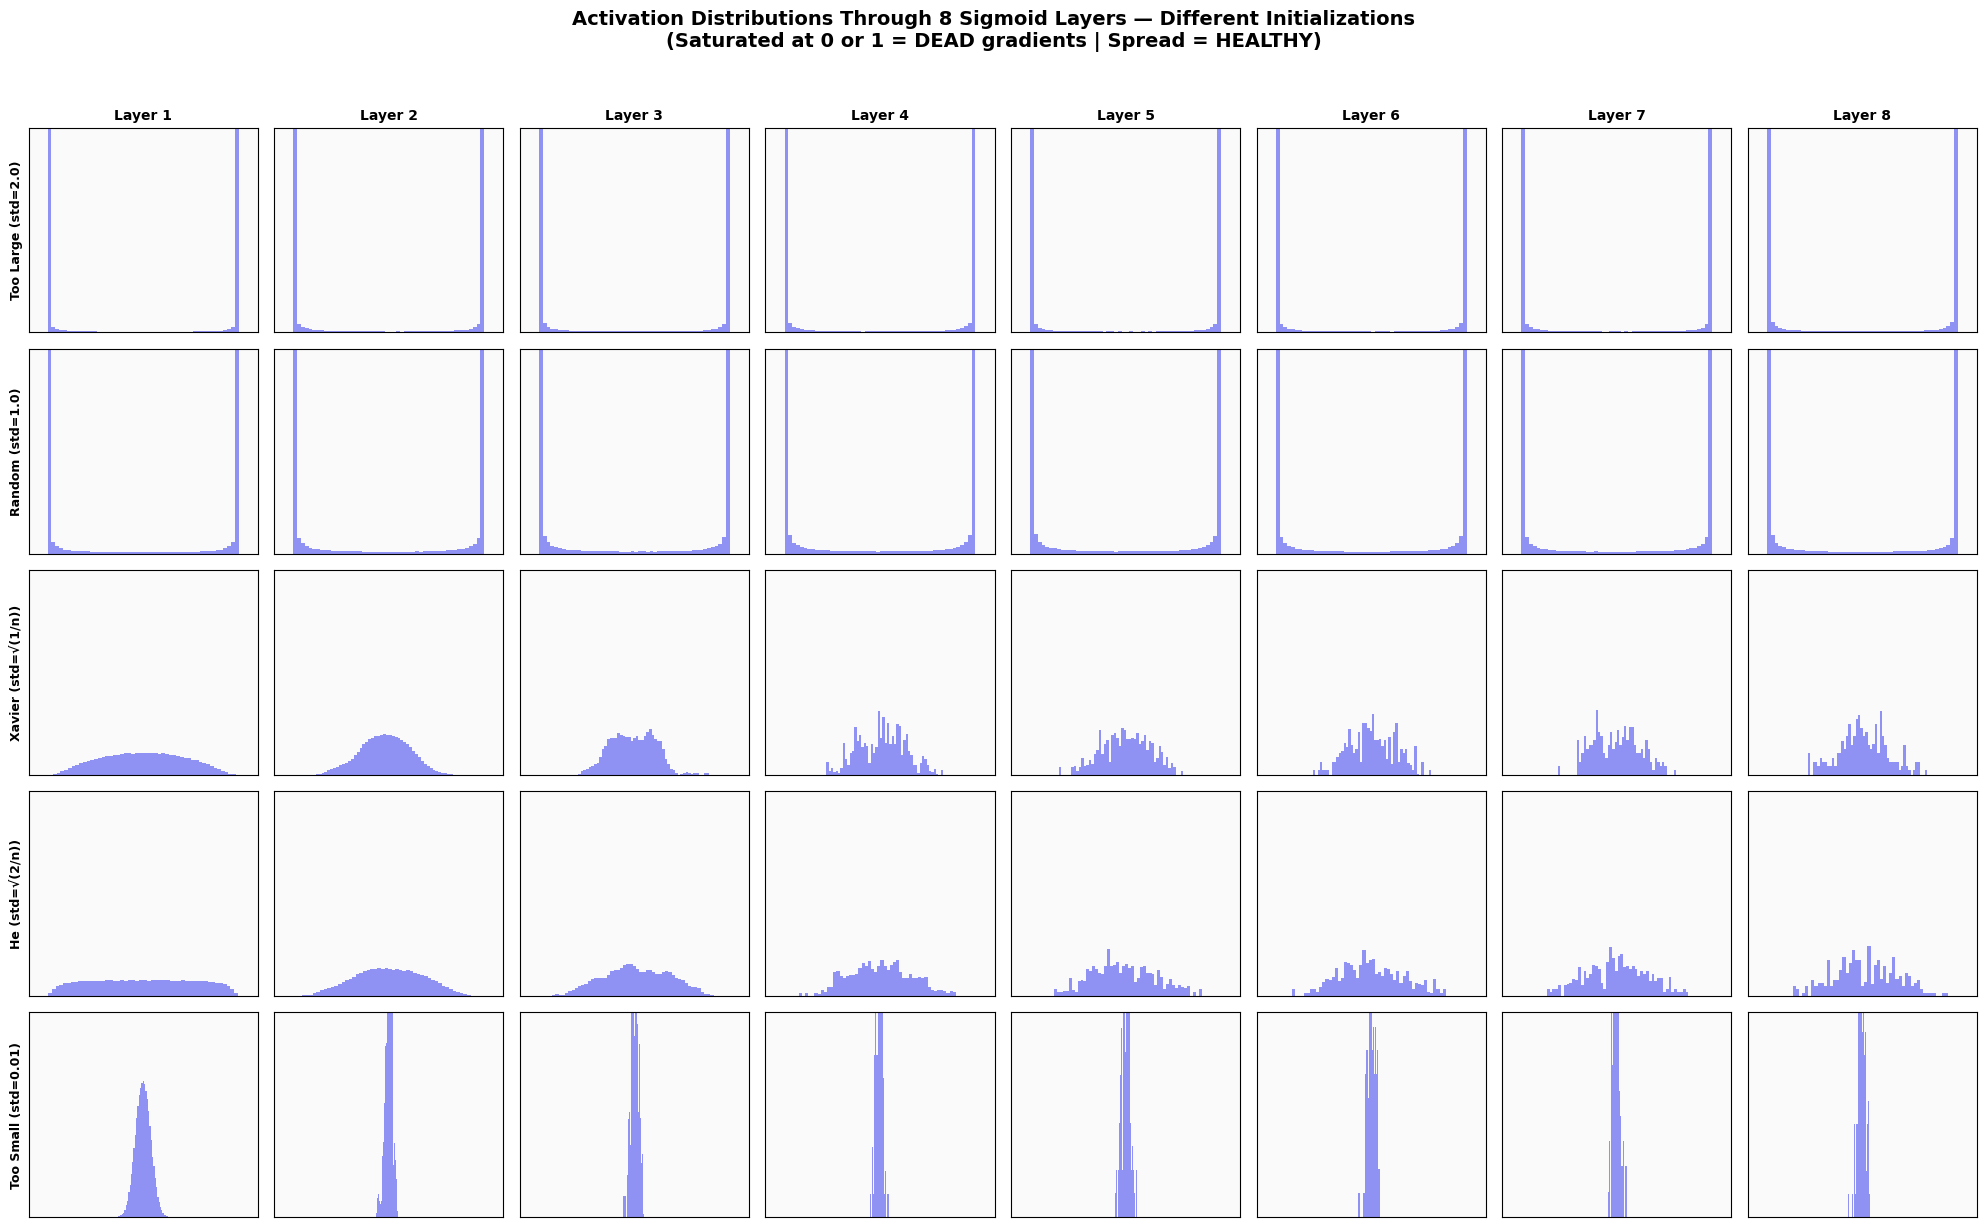

📌 Too Large: activations saturate at 0 or 1 → gradients = 0 (DEAD)
📌 Random: quickly saturates → vanishing gradient
📌 Xavier: maintains distribution → best for sigmoid/tanh (ව්‍යාප්තිය හොඳින් පවත්වා ගන්නවා)
📌 He: slightly wider → designed for ReLU
📌 Too Small: all activations ≈ 0.5 → no discriminative power


In [23]:
# ============================================================
# Weight Init Impact on Activation Distribution
# ============================================================

np.random.seed(42)

n_layers = 8
layer_width = 256
X_init = np.random.randn(500, 256)

inits = {
 'Too Large (std=2.0)': 2.0,
 'Random (std=1.0)': 1.0,
 'Xavier (std=√(1/n))': np.sqrt(1.0 / layer_width),
 'He (std=√(2/n))': np.sqrt(2.0 / layer_width),
 'Too Small (std=0.01)': 0.01,
}

fig, axes = plt.subplots(len(inits), n_layers, figsize=(20, 12))

for row, (init_name, std) in enumerate(inits.items()):
 out = X_init.copy()
 
 for col in range(n_layers):
 W = np.random.randn(layer_width, layer_width) * std
 out = 1 / (1 + np.exp(-np.clip(out @ W, -500, 500))) # sigmoid
 
 ax = axes[row, col]
 ax.hist(out.flatten(), bins=50, color='#6366f1', alpha=0.7, density=True)
 ax.set_xlim(-0.1, 1.1)
 ax.set_ylim(0, 15)
 
 if row == 0:
 ax.set_title(f'Layer {col+1}', fontsize=10, fontweight='bold')
 if col == 0:
 ax.set_ylabel(init_name, fontsize=9, fontweight='bold')
 
 ax.set_xticks([])
 ax.set_yticks([])

plt.suptitle('Activation Distributions Through 8 Sigmoid Layers — Different Initializations\n'
 '(Saturated at 0 or 1 = DEAD gradients | Spread = HEALTHY)',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Too Large: activations saturate at 0 or 1 → gradients = 0 (DEAD)")
print(" Random: quickly saturates → vanishing gradient")
print(" Xavier: maintains distribution → best for sigmoid/tanh (ව්යාප්තිය හොඳින් පවත්වා ගන්නවා)")
print(" He: slightly wider → designed for ReLU")
print(" Too Small: all activations ≈ 0.5 → no discriminative power")

---

<a id="8"></a>
## 8. Solution 3: Batch Normalization

**Batch Normalization** (Ioffe & Szegedy, 2015) — මේකෙන් කරන්නේ හැම layer එකකටම යන input එක normalize කරන එකයි. (Mean එක 0 ටත්, Variance එක 1 ටත් ගේනවා).

### How it helps (මේකෙන් ලැබෙන වාසි):
1. Activations වල අගයන් "reasonable range" (ආරක්ෂිත පරාසයක්) එකක තියාගන්නවා.
2. අගයන් ගොඩක් ලොකු/පොඩි වෙන්නේ නැති නිසා Sigmoid saturate වෙන්නේ නැහැ.
3. Gradient flow එක stable වෙනවා.
4. Higher learning rates (විශාල learning rates) පාවිච්චි කරන්න පුළුවන් වෙනවා, ඒ නිසා ඉක්මනට train වෙනවා.

### Formula:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

මෙතන $\gamma$ (scale) සහ $\beta$ (shift) කියන්නේ **learnable** parameters. ඒ කියන්නේ network එක ඒවත් ඉගෙන ගන්නවා.

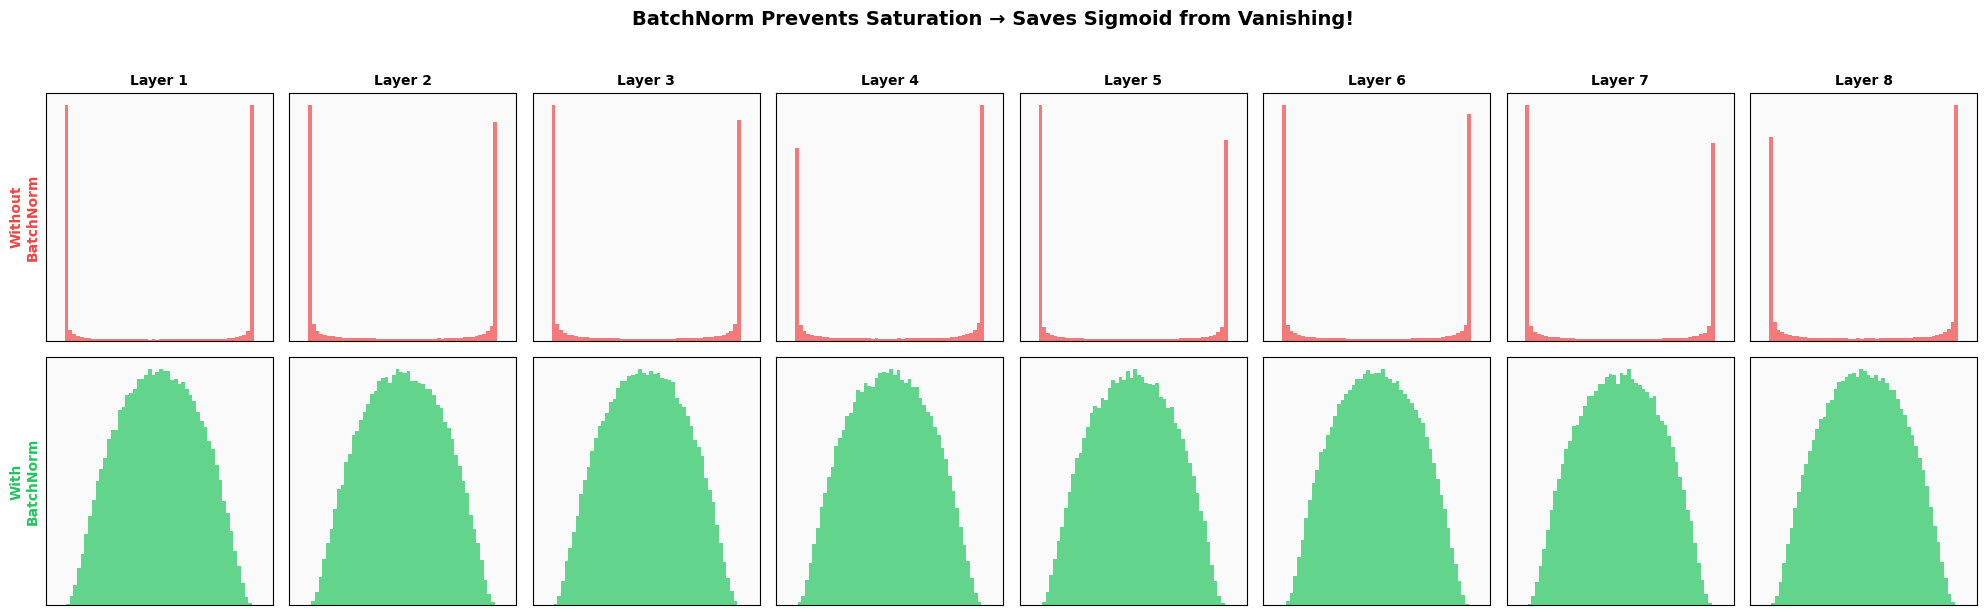

📌 WITHOUT BatchNorm: activations saturate at 0 or 1 by layer 3 → dead gradients (ලේයර් 3ක් යනකොට අගයන් සීමාවට ගිහින් gradient එක මැරෙනවා)
📌 WITH BatchNorm: activations stay centered → gradients survive! (අගයන් මැදට වෙලා තියෙන නිසා gradient එක ආරක්ෂා වෙනවා)

💡 BUT: Even with BatchNorm, ReLU is still preferred over Sigmoid for hidden layers (නමුත් BatchNorm දැම්මත් hidden layers වලට ReLU පාවිච්චි කරන එක වඩාත් සුදුසුයි)


In [24]:
# ============================================================
# Batch Norm Effect on Activation Distributions
# ============================================================

np.random.seed(42)

n_layers = 8
layer_width = 256
X_bn = np.random.randn(500, 256)

fig, axes = plt.subplots(2, n_layers, figsize=(20, 6))

# Row 1: WITHOUT BatchNorm
out = X_bn.copy()
for col in range(n_layers):
 W = np.random.randn(layer_width, layer_width) * 1.0
 z = out @ W
 out = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
 
 ax = axes[0, col]
 ax.hist(out.flatten(), bins=50, color='#ef4444', alpha=0.7, density=True)
 ax.set_xlim(-0.1, 1.1)
 ax.set_title(f'Layer {col+1}', fontsize=10, fontweight='bold')
 if col == 0:
 ax.set_ylabel('Without\nBatchNorm', fontsize=10, fontweight='bold', color='#ef4444')
 ax.set_xticks([])
 ax.set_yticks([])

# Row 2: WITH BatchNorm
out = X_bn.copy()
for col in range(n_layers):
 W = np.random.randn(layer_width, layer_width) * 1.0
 z = out @ W
 
 # BatchNorm: normalize z before activation
 z_norm = (z - z.mean(axis=0)) / (z.std(axis=0) + 1e-8)
 
 out = 1 / (1 + np.exp(-np.clip(z_norm, -500, 500)))
 
 ax = axes[1, col]
 ax.hist(out.flatten(), bins=50, color='#22c55e', alpha=0.7, density=True)
 ax.set_xlim(-0.1, 1.1)
 if col == 0:
 ax.set_ylabel('With\nBatchNorm', fontsize=10, fontweight='bold', color='#22c55e')
 ax.set_xticks([])
 ax.set_yticks([])

plt.suptitle('BatchNorm Prevents Saturation → Saves Sigmoid from Vanishing!',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" WITHOUT BatchNorm: activations saturate at 0 or 1 by layer 3 → dead gradients (ලේයර් 3ක් යනකොට අගයන් සීමාවට ගිහින් gradient එක මැරෙනවා)")
print(" WITH BatchNorm: activations stay centered → gradients survive! (අගයන් මැදට වෙලා තියෙන නිසා gradient එක ආරක්ෂා වෙනවා)")
print("\n BUT: Even with BatchNorm, ReLU is still preferred over Sigmoid for hidden layers (නමුත් BatchNorm දැම්මත් hidden layers වලට ReLU පාවිච්චි කරන එක වඩාත් සුදුසුයි)")

---

<a id="9"></a>
## 9. Solution 4: Residual Connections (Skip Connections)

**ResNets** (He et al., 2015) කියන අලුත් architecture එකෙන් gradient එකට ලේයර්ස් අතරින් කෙලින්ම ගමන් කරන්න (flow කරන්න) shortcut path එකක් (skip connection) හදලා දුන්නා.

### Regular Layer (සාමාන්ය ලේයරයකදී):
$$y = F(x)$$

### Residual Layer (Skip Connection එකක් එක්ක):
$$y = F(x) + x \quad \leftarrow \text{skip connection! (අතරමගින් යන කෙටි පාර)}$$

### Why it Works (මේක වැඩ කරන්නේ කොහොමද?):

```text
 ┌──────────────────────┐
 │ Skip/Identity │
 x ────────────▶│ Connection │─────── (+) ────▶ y
 │ └──────────────────────┘ ↑
 │ │
 └───▶ [Conv/Dense] ──▶ [BN] ──▶ [ReLU] ──▶ [Conv/Dense] ──┘
 F(x)
```

Gradient of skip connection: $\frac{\partial(F(x) + x)}{\partial x} = \frac{\partial F}{\partial x} + \mathbf{1}$

**අර එකතු වෙන 1 නිසා (The +1 guarantees) gradient එක හැමතිස්සෙම 1 ට වඩා වැඩි වෙනවා හෝ සමාන වෙනවා!** 
ලේයරය ඇතුලේ තියෙන F(x) ගේ gradient එක 0 වෙලා vanish වුනත්, gradient එක අර shortcut path (identity path) එකෙන් කිසිම කරදරයක් නැතුව පහලට යනවා.

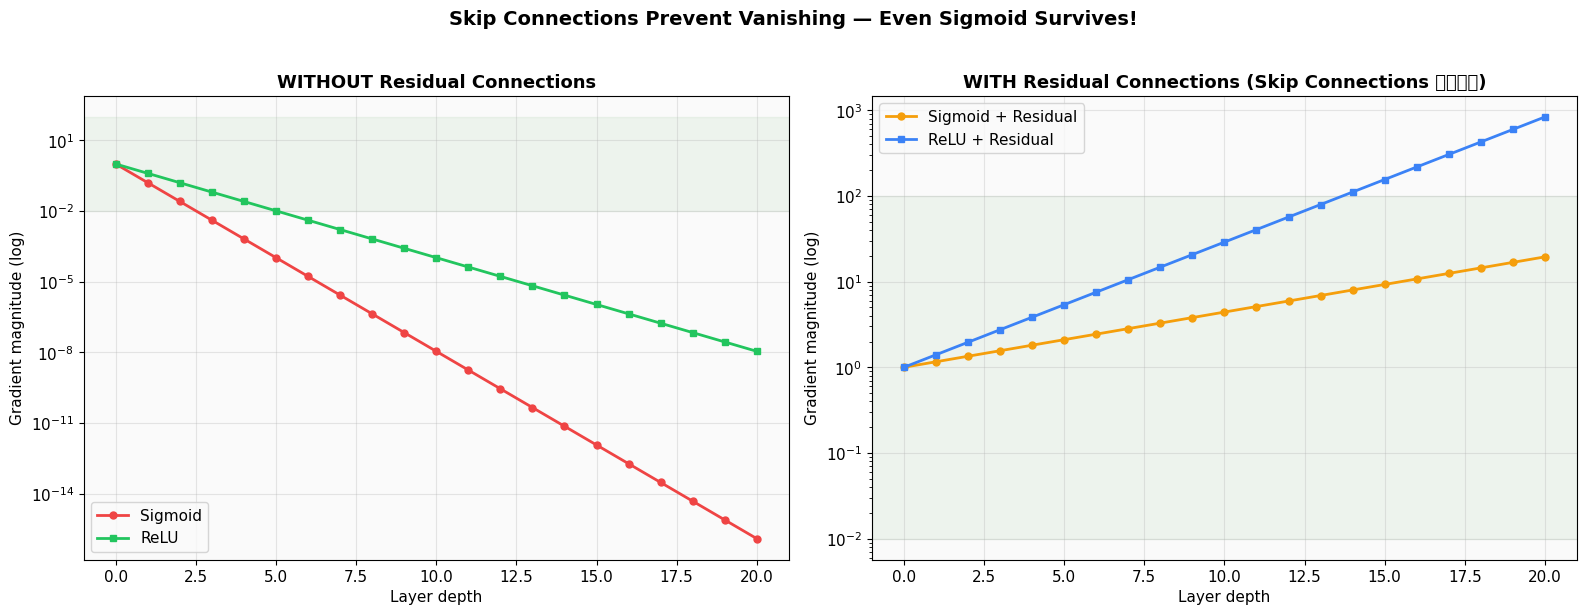


📊 Gradient at Layer 20 (ලේයර් 20 දී Gradient අගය):
   Sigmoid (no skip):         1.21e-16 💀
   ReLU (no skip):            1.10e-08
   Sigmoid + Residual:        1.95e+01 ✅ Saved! (Sigmoid වුනත් skip connection නිසා බේරුනා!)
   ReLU + Residual:           8.37e+02 ✅

💡 Residual connections allow networks with 100+ layers (ResNet-152!) (මේ නිසා තමයි අද කාලේ layers 150+ තියෙන networks හදන්න පුළුවන් වෙලා තියෙන්නේ)


In [25]:
# ============================================================
# Residual Connections vs Regular — Gradient Flow
# ============================================================

np.random.seed(42)

def simulate_gradient_flow(n_layers, use_residual=False, activation='sigmoid'):
 """Simulate gradient flow through layers with optional residual connections."""
 gradient = 1.0
 gradients = [gradient]
 
 for i in range(n_layers):
 # Activation derivative (average)
 if activation == 'sigmoid':
 act_grad = 0.20 # typical sigmoid derivative
 elif activation == 'relu':
 act_grad = 0.5 # ~50% of neurons active
 
 weight_scale = 0.8 # typical weight contribution
 layer_grad = act_grad * weight_scale
 
 if use_residual:
 # Residual: gradient = layer_grad + 1 (skip connection)
 gradient = gradient * layer_grad + gradient # F'(x) * grad + grad
 else:
 gradient = gradient * layer_grad
 
 gradients.append(gradient)
 
 return gradients


n = 20
grads_sigmoid = simulate_gradient_flow(n, use_residual=False, activation='sigmoid')
grads_relu = simulate_gradient_flow(n, use_residual=False, activation='relu')
grads_sigmoid_res = simulate_gradient_flow(n, use_residual=True, activation='sigmoid')
grads_relu_res = simulate_gradient_flow(n, use_residual=True, activation='relu')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

layers = np.arange(n + 1)

# Without residual
ax = axes[0]
ax.semilogy(layers, grads_sigmoid, 'o-', color='#ef4444', linewidth=2, label='Sigmoid', markersize=5)
ax.semilogy(layers, grads_relu, 's-', color='#22c55e', linewidth=2, label='ReLU', markersize=5)
ax.set_title('WITHOUT Residual Connections', fontsize=13, fontweight='bold')
ax.set_xlabel('Layer depth')
ax.set_ylabel('Gradient magnitude (log)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhspan(0.01, 100, alpha=0.05, color='green')

# With residual
ax = axes[1]
ax.semilogy(layers, grads_sigmoid_res, 'o-', color='#f59e0b', linewidth=2, label='Sigmoid + Residual', markersize=5)
ax.semilogy(layers, grads_relu_res, 's-', color='#3b82f6', linewidth=2, label='ReLU + Residual', markersize=5)
ax.set_title('WITH Residual Connections (Skip Connections එක්ක)', fontsize=13, fontweight='bold')
ax.set_xlabel('Layer depth')
ax.set_ylabel('Gradient magnitude (log)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhspan(0.01, 100, alpha=0.05, color='green')

plt.suptitle('Skip Connections Prevent Vanishing — Even Sigmoid Survives!', 
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Gradient at Layer 20 (ලේයර් 20 දී Gradient අගය):")
print(f" Sigmoid (no skip): {grads_sigmoid[-1]:.2e} ")
print(f" ReLU (no skip): {grads_relu[-1]:.2e}")
print(f" Sigmoid + Residual: {grads_sigmoid_res[-1]:.2e} Saved! (Sigmoid වුනත් skip connection නිසා බේරුනා!)")
print(f" ReLU + Residual: {grads_relu_res[-1]:.2e} ")
print(f"\n Residual connections allow networks with 100+ layers (ResNet-152!) (මේ නිසා තමයි අද කාලේ layers 150+ තියෙන networks හදන්න පුළුවන් වෙලා තියෙන්නේ)")

---

<a id="10"></a>
## 10. Comprehensive Comparison — All Solutions

අපි කතා කරපු හැම solution එකක්ම එකට දාලා බලමු කොයි එකද වඩාත් සාර්ථක කියලා.

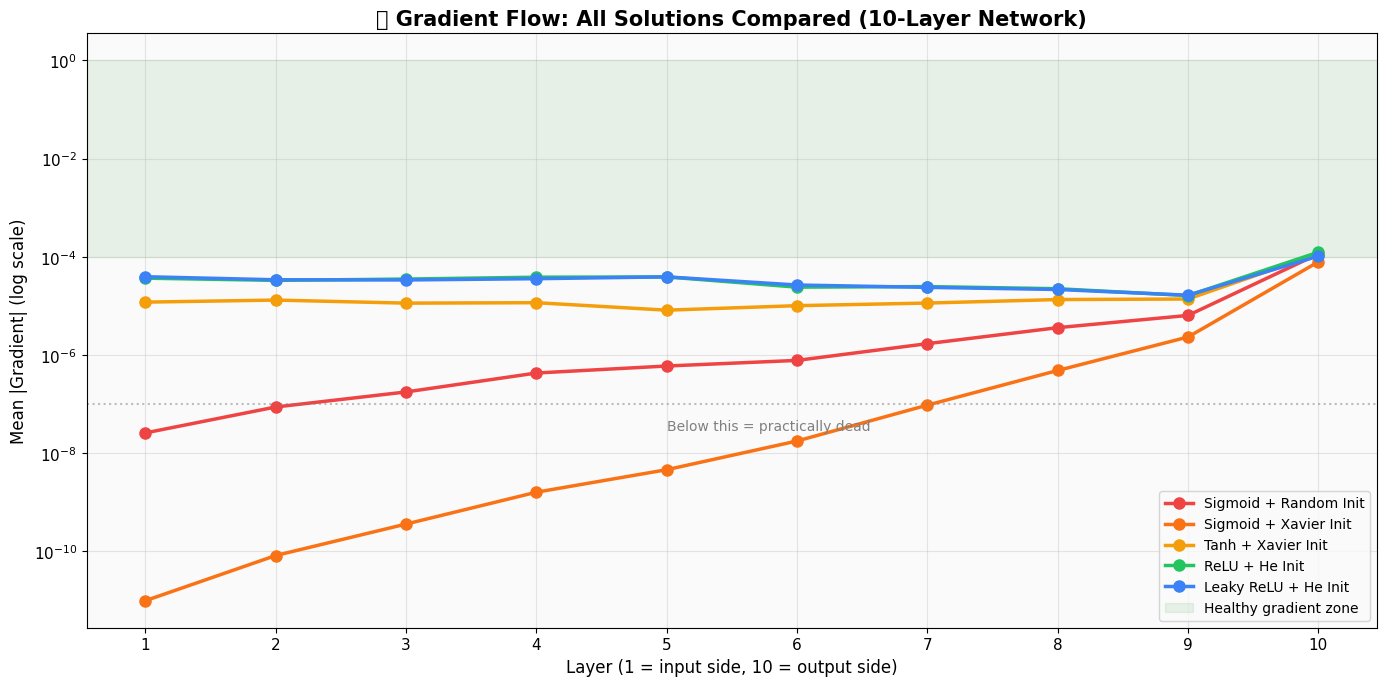


🏆 RANKING (by gradient health at Layer 1):
Rank   Configuration                  Layer 1 Gradient   Verdict
───────────────────────────────────────────────────────────────────────────
🥇      Leaky ReLU + He Init           3.91e-05           ⚠️ Weak
🥈      ReLU + He Init                 3.65e-05           ⚠️ Weak
🥉      Tanh + Xavier Init             1.19e-05           ⚠️ Weak
4️⃣    Sigmoid + Random Init          2.57e-08           ⚠️ Weak
5️⃣    Sigmoid + Xavier Init          9.81e-12           💀 DEAD


In [26]:
# ============================================================
# Final Comparison: All Solutions on Deep Network
# ============================================================

np.random.seed(42)

configs = {
 'Sigmoid + Random Init': {'act': 'sigmoid', 'init': 'random'},
 'Sigmoid + Xavier Init': {'act': 'sigmoid', 'init': 'xavier'},
 'Tanh + Xavier Init': {'act': 'tanh', 'init': 'xavier'},
 'ReLU + He Init': {'act': 'relu', 'init': 'he'},
 'Leaky ReLU + He Init': {'act': 'leaky_relu', 'init': 'he'},
}

layer_sizes = [10] + [32] * 9 + [1]
X_comp = np.random.randn(128, 10)
y_comp = np.random.randint(0, 2, (128, 1)).astype(float)

fig, ax = plt.subplots(figsize=(14, 7))

colors_map = {
 'Sigmoid + Random Init': '#ef4444',
 'Sigmoid + Xavier Init': '#f97316',
 'Tanh + Xavier Init': '#f59e0b',
 'ReLU + He Init': '#22c55e',
 'Leaky ReLU + He Init': '#3b82f6',
}

for name, cfg in configs.items():
 np.random.seed(42)
 net = DeepNet(layer_sizes, activation=cfg['act'], init=cfg['init'])
 net.forward(X_comp)
 grads = net.backward(y_comp)
 
 grads_safe = [max(g, 1e-20) for g in grads]
 ax.semilogy(range(1, len(grads_safe)+1), grads_safe, 'o-', 
 color=colors_map[name], linewidth=2.5, markersize=8, label=name)

ax.axhspan(1e-4, 1, alpha=0.08, color='green', label='Healthy gradient zone')
ax.axhline(y=1e-7, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Below this = practically dead', xy=(5, 3e-8), fontsize=10, color='gray')

ax.set_xlabel('Layer (1 = input side, 10 = output side)', fontsize=12)
ax.set_ylabel('Mean |Gradient| (log scale)', fontsize=12)
ax.set_title(' Gradient Flow: All Solutions Compared (10-Layer Network)', 
 fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

print("\n RANKING (by gradient health at Layer 1):")
print(f"{'Rank':<6} {'Configuration':<30} {'Layer 1 Gradient':<18} {'Verdict'}")
print("─" * 75)

ranking = []
for name, cfg in configs.items():
 np.random.seed(42)
 net = DeepNet(layer_sizes, activation=cfg['act'], init=cfg['init'])
 net.forward(X_comp)
 grads = net.backward(y_comp)
 ranking.append((name, grads[0]))

ranking.sort(key=lambda x: x[1], reverse=True)
for i, (name, g) in enumerate(ranking):
 verdict = ' DEAD' if g < 1e-8 else ' Weak' if g < 1e-4 else ' Healthy' if g < 1 else ' Excellent'
 medal = ['', '', '', '4⃣', '5⃣'][i]
 print(f"{medal:<6} {name:<30} {g:<18.2e} {verdict}")

---

<a id="11"></a>
## 11. Summary & Best Practices

### The Vanishing Gradient Problem (ප්රශ්නය සාරාංශයක් ලෙස):

```text
┌──────────────────────────────────────────────────────────────────┐
│ ROOT CAUSE: Sigmoid derivative is ALWAYS ≤ 0.25 (ප්රධාන හේතුව) │
│ │
│ Each layer multiplies gradient by ≤ 0.25 │
│ After N layers: gradient ≤ 0.25^N │
│ │
│ N=5: 0.25^5 = 0.001 (weak) │
│ N=10: 0.25^10 = 0.000001 (practically dead - බිංදුවයි) │
│ N=20: 0.25^20 = 10^(-12) (absolutely dead) │
│ │
│ RESULT: Early layers cannot learn → deep networks fail │
│ ප්රතිඵලය: මුල් ලේයර්ස් ඉගෙනගන්නේ නෑ, ඒ නිසා network එක fail වෙනවා.│
└──────────────────────────────────────────────────────────────────┘
```

### Solutions Summary (විසඳුම්):

| Solution | How it Helps | Impact |
|----------|-------------|--------|
| **ReLU** | Gradient = 1 (not 0.25) for active neurons | Most important |
| **He Initialization** | Keeps activations in good range | Essential with ReLU |
| **Batch Normalization** | Prevents activation saturation | Standard practice |
| **Residual Connections** | Gradient highway (skip path) | Enables 100+ layers |
| **Gradient Clipping** | Caps exploding gradients | For RNNs |
| **LSTM/GRU** | Gated gradient flow | For sequences (RNNs වලදී) |

### Modern Best Practices (අද කාලයේ පාවිච්චි කරන හොඳම ක්රම):

```python
# DO: Modern deep network recipe
model = Sequential([
 Dense(256, activation='relu'), # Sigmoid වෙනුවට ReLU භාවිතා කරන්න
 BatchNorm(), # Activations normalize කරන්න
 Dropout(0.2), # Regularization සඳහා
 Dense(128, activation='relu'),
 BatchNorm(),
 Dense(10, activation='softmax'), # Output layer එකට පමණක් Softmax/Sigmoid දාන්න
])

# ReLU සඳහා He initialization පාවිච්චි অফিসে
# Adam optimizer පාවිච්චි කරන්න
```

### When to STILL Use Sigmoid (Sigmoid පාවිච්චි කළ යුත්තේ කොතැනද?):

| Use Case | Activation | Why (ඇයි?) |
|----------|-----------|-----|
| Binary classification **output** | Sigmoid | Output එක 0 ත් 1 ත් අතර Probability එකක් ලෙස ලබාගැනීමට |
| Multi-label classification output | Sigmoid | Independent probabilities per class |
| Gating mechanisms (LSTM, GRU) | Sigmoid | Need 0-1 range for gates (දොරටු විවෘත කිරීම/වැසීම සඳහා) |
| Attention weights | Sigmoid/Softmax | Need bounded values (අගයන් සීමා කිරීමට) |

### When NEVER to Use Sigmoid (Sigmoid පාවිච්චි නොකළ යුත්තේ කොතැනද?):

- **Hidden layers** — hidden layers වලට Sigmoid වෙනුවට ReLU/LeakyReLU/GELU පාවිච්චි කරන්න.
- **Deep networks** (layers 3කට වඩා වැඩි නම්) — gradient එක අනිවාර්යයෙන්ම vanish වෙනවා.
- **When speed matters** — exp() ගණනය කිරීම, max(0,z) ගණනය කිරීමට වඩා ගොඩක් අමාරුයි/වෙලා යනවා.